<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 2.3}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} &  Sita Zoe Sotomayor Carrillo \\[6pt]
\textbf{Fecha de realización:} & 25/02/2026
\end{array}

</center>

#Parte 2: Convolución

Dada la imagen I = [[1,2,0],[0,1,3],[2,1,0]]

Y el kernel K = [[1,0],[-1,1]]

Aplicar convolución 2D sin padding y stride 1.

Preguntas:

- ¿Qué cambia si se agrega padding?
- ¿Cómo impacta el tamaño del kernel en el costo computacional?


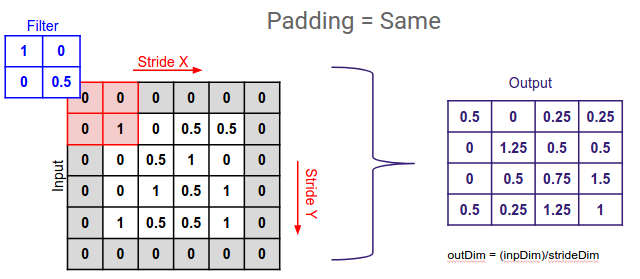

In [ ]:
import numpy as np

# Definimos la imagen I y el kernel K
I = np.array([[1, 2, 0],
              [0, 1, 3],
              [2, 1, 0]])

K = np.array([[1, 0],
              [-1, 1]])

def convolution2d(image, kernel):
    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape

    # Sin padding y stride 1, el tamaño de salida es (N - K + 1)
    out_h = img_h - ker_h + 1
    out_w = img_w - ker_w + 1

    output = np.zeros((out_h, out_w))

    for i in range(out_h):
        for j in range(out_w):
            # Extraemos la región de interés (ventana)
            region = image[i:i+ker_h, j:j+ker_w]
            # Multiplicación elemento a elemento y suma
            output[i, j] = np.sum(region * kernel)

    return output

resultado = convolution2d(I, K)
print("Resultado de la convolución:")
print(resultado)

Resultado de la convolución:
[[ 2.  4.]
 [-1.  0.]]


**¿Qué cambia si se agrega padding?**

El padding (relleno de ceros en los bordes) tiene dos efectos principales:

Mantiene el tamaño: Sin padding, la imagen se encoge en cada capa de convolución. Con el padding adecuado, la salida tiene las mismas dimensiones que la entrada ($3 \times 3$ en tu caso).

Información de los bordes: Sin padding, los píxeles de las esquinas solo se procesan una vez, mientras que los centrales participan en múltiples ventanas. El padding permite que la red "aproveche" mejor la información de los bordes.

**¿Cómo impacta el tamaño del kernel en el costo computacional?**

El impacto es cuadrático.Si tienes un kernel de $k \times k$, por cada píxel de salida realizas $k^2$ multiplicaciones y sumas.

Si duplicas el tamaño del kernel (de $3 \times 3$ a $6 \times 6$), el costo computacional no se duplica, sino que se cuadruplica (pasas de 9 a 36 operaciones por paso).

En modelos grandes, esto puede ralentizar significativamente el entrenamiento, por lo que a menudo se prefieren varios kernels pequeños (como $3 \times 3$) apilados en lugar de uno muy grande.

**Cálculo Manual (para verificar)**

Si quieres comprobar el código, el resultado debería ser:

Posición (0,0): $(1 \times 1) + (2 \times 0) + (0 \times -1) + (1 \times 1) = 2$

Posición (0,1): $(2 \times 1) + (0 \times 0) + (1 \times -1) + (3 \times 1) = 4$

Posición (1,0): $(0 \times 1) + (1 \times 0) + (2 \times -1) + (1 \times 1) = -1$

Posición (1,1): $(1 \times 1) + (3 \times 0) + (1 \times -1) + (0 \times 1) = 0$


Resultado Final:$$\begin{bmatrix} 2 & 4 \\ -1 & 0 \end{bmatrix}$$

# **Ejercicio Adicional: Multiplicación de matrices de tamaño nxn**

Crear una función que reciba el tamaño de la matriz n y muestre el resultado de la multiplicación. Para eso se recomienda crear matrices cuadradas de tamaño 10×10, 100×100, 1000×1000 y 10000 x10000, o hasta donde el poder de su computadora lo soporte. Llenarlas con numero aleatorios del 0 al 99 y que sirva como base para implementar una función de multiplicación de matrices. Ejecutar la multiplicación y mostrar resultados (parcialmente para tamaños grandes) del tamaño que se indique.


<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>

In [1]:
import numpy as np
import time

# --- HERRAMIENTA DE MEDICIÓN ---
def medir_tiempo(func):
    def wrapper(*args, **kwargs):
        inicio = time.time()
        res = func(*args, **kwargs)
        fin = time.time()
        print(f"[Rendimiento] {func.__name__} con N={args[0]} tardó: {(fin-inicio):.4f} segundos")
        return res
    return wrapper

# --- PARTE 1: MULTIPLICACIÓN MATRICIAL N x N ---
@medir_tiempo
def multiplicacion_matrices_nxn(n):
    print(f"\n--- Generando matrices {n}x{n} ---")
    # Usamos enteros aleatorios entre 0 y 99
    A = np.random.randint(0, 100, size=(n, n))
    B = np.random.randint(0, 100, size=(n, n))

    # Multiplicación optimizada con producto punto (dot product)
    # Nota: Hacer esto con bucles for anidados en Python puro para N=1000 tardaría horas.
    # NumPy usa C y BLAS por debajo, haciéndolo en segundos.
    C = np.dot(A, B)

    # Mostrar vista previa si es muy grande
    if n > 10:
        print("Resultado parcial (esquina superior izquierda 5x5):")
        print(C[:5, :5])
        print("...")
    else:
        print("Resultado completo:")
        print(C)
    return C

# --- PARTE 2: CONVOLUCIÓN 2D MANUAL ---
def convolucion_2d(imagen, kernel):
    filas_img, cols_img = imagen.shape
    filas_k, cols_k = kernel.shape

    # Dimensiones de salida (sin padding, stride 1)
    filas_salida = filas_img - filas_k + 1
    cols_salida = cols_img - cols_k + 1

    salida = np.zeros((filas_salida, cols_salida))

    print(f"\n--- Aplicando Convolución (Imagen {filas_img}x{cols_img}, Kernel {filas_k}x{cols_k}) ---")

    for i in range(filas_salida):
        for j in range(cols_salida):
            # Extraer la región de interés (ROI)
            region = imagen[i:i+filas_k, j:j+cols_k]
            # Operación de convolución: suma del producto elemento a elemento
            valor = np.sum(region * kernel)
            salida[i, j] = valor

    return salida

# --- EJECUCIÓN ---
# 1. Ejercicio de Matrices Grandes
# Tamaños recomendados: 10, 100, 1000
for n in [10, 100, 1000, 2000]:
    try:
        multiplicacion_matrices_nxn(n)
    except MemoryError:
        print(f"N={n} es demasiado grande para la memoria RAM disponible.")

# 2. Ejercicio de Convolución
I = np.array([
    [1, 2, 0],
    [0, 1, 3],
    [2, 1, 0]
])

K = np.array([
    [1, 0],
    [-1, 1]
])

resultado_conv = convolucion_2d(I, K)
print("\nResultado Convolución:")
print(resultado_conv)


--- Generando matrices 10x10 ---
Resultado completo:
[[17900 23909 23129 31049 36837 25551 24353 26508 40381 22185]
 [13201 11193 17908 19083 27217 16764 15723 22045 21665 12824]
 [10308 20408 17788 21449 21613 18880 15943 19866 27190 15621]
 [ 7565 13676 14044 13656 15653 11893 13079 17379 20604 12791]
 [18450 23926 29374 39279 34261 20204 23691 27935 38067 21012]
 [20419 22727 30087 35936 38276 25423 24414 32275 38806 21729]
 [24710 23661 33597 34898 42078 29220 28649 36990 44562 24734]
 [17527 21842 25493 24393 32671 24654 23091 34040 38020 22984]
 [13770 18227 20353 17382 22984 20068 17861 24890 29178 18482]
 [16352 18007 19634 23772 31560 21653 18628 25844 31469 18720]]
[Rendimiento] multiplicacion_matrices_nxn con N=10 tardó: 0.0121 segundos

--- Generando matrices 100x100 ---
Resultado parcial (esquina superior izquierda 5x5):
[[262854 275174 240614 264232 247173]
 [236527 247128 239253 235135 226917]
 [274090 273135 269807 269632 259955]
 [230612 230573 213300 222777 221042]
 